<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Practice_Work/Logistic_Reg_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
path="/content/insurance_data.xlsx"
path

'/content/insurance_data.xlsx'

In [3]:
import pandas as pd
df=pd.read_excel(path)
df

,Age,Gender,BMI,Smoker,Diabetic,AnnualIncome,VehicleAge,PreviousClaims,CreditScore,PolicyApproved
0,58,Male,18.6,No,Yes,668106,4,5,404,0
1,61,Male,31.0,Yes,Yes,396493,6,1,817,0
2,56,Male,30.3,No,Yes,1142059,18,2,306,0
3,66,Male,33.4,No,No,526064,6,2,404,0
4,23,Female,20.1,No,No,1892670,1,5,770,1
...,...,...,...,...,...,...,...,...,...,...
195,29,Female,33.2,No,No,1880129,2,5,734,1
196,23,Female,31.3,Yes,No,873629,3,0,635,0
197,60,Female,24.7,No,Yes,1646541,14,2,757,1
198,20,Female,31.5,No,No,1541064,1,0,715,1


In [4]:
df.columns


Index(['Age', 'Gender', 'BMI', 'Smoker', 'Diabetic', 'AnnualIncome',
       'VehicleAge', 'PreviousClaims', 'CreditScore', 'PolicyApproved'],
      dtype='object')

In [5]:
X=[['Age', 'Gender', 'BMI', 'Smoker', 'Diabetic', 'AnnualIncome',
       'VehicleAge', 'PreviousClaims', 'CreditScore']]
y=["PolicyApproved"]

In [6]:
df.isna().sum()

,0
Age,0
Gender,0
BMI,0
Smoker,0
Diabetic,0
AnnualIncome,0
VehicleAge,0
PreviousClaims,0
CreditScore,0
PolicyApproved,0


In [7]:
# Split the dataset

from sklearn.model_selection import train_test_split

# Correctly define X and y from the df DataFrame
feature_cols = ['Age', 'Gender', 'BMI', 'Smoker', 'Diabetic', 'AnnualIncome', 'VehicleAge', 'PreviousClaims', 'CreditScore']
target_col = 'PolicyApproved'
X = df[feature_cols]
y = df[target_col]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2, random_state=42) # Added random_state for reproducibility

In [8]:
# Training
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Identify categorical columns that need encoding
categorical_cols = ['Gender', 'Smoker', 'Diabetic']

# Apply one-hot encoding to training and testing data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

model = LogisticRegression(max_iter=1000) # Increased max_iter as a good practice for convergence
model.fit(X_train_encoded, y_train)

# Testing
y_pred = model.predict(X_test_encoded)

# Check data score
print('Train Data Score:',model.score(X_train_encoded,y_train))
print('Test Data Score:',model.score(X_test_encoded,y_test))

Train Data Score: 0.86875
Test Data Score: 0.925


In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

In [10]:
# actual output and Predicted output
df= confusion_matrix(y_test,y_pred)
df

array([[29,  2],
       [ 1,  8]])

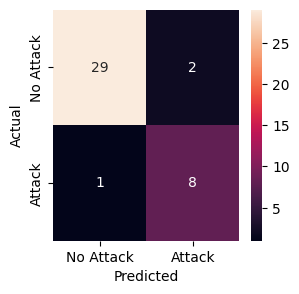

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
sns.heatmap(df,annot=True,fmt='d',xticklabels=['No Attack','Attack'],yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
accuracy_score(y_test,y_pred)*100

92.5

In [13]:
precision_score(y_test,y_pred)*100

80.0

In [14]:
recall_score(y_test,y_pred)*100

88.88888888888889

In [15]:
f1_score(y_test,y_pred)*100

84.21052631578947

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        31
           1       0.80      0.89      0.84         9

    accuracy                           0.93        40
   macro avg       0.88      0.91      0.90        40
weighted avg       0.93      0.93      0.93        40



In [17]:
# Lets use Decision Tree algorithm on the same data

from sklearn.tree import DecisionTreeClassifier

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_encoded, y_train)
dt_pred = dt_model.predict(X_test_encoded)

In [21]:
print('Training score:',dt_model.score(X_train_encoded,y_train)*100)
print('Testing score:',dt_model.score(X_test_encoded,y_test)*100)

Training score: 100.0
Testing score: 82.5


In [22]:
# Assignment: Test on other algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

### K-Nearest Neighbors (KNN)

KNN Training score: 75.0
KNN Testing score: 80.0


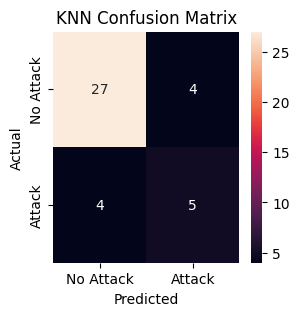

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        31
           1       0.56      0.56      0.56         9

    accuracy                           0.80        40
   macro avg       0.71      0.71      0.71        40
weighted avg       0.80      0.80      0.80        40



In [27]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_encoded, y_train)
knn_pred = knn_model.predict(X_test_encoded)

print('KNN Training score:', knn_model.score(X_train_encoded, y_train) * 100)
print('KNN Testing score:', knn_model.score(X_test_encoded, y_test) * 100)

knn_cm = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(3,3))
sns.heatmap(knn_cm, annot=True, fmt='d', xticklabels=['No Attack','Attack'], yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

print('KNN Classification Report:')
print(classification_report(y_test, knn_pred))

### Support Vector Classifier (SVC)

SVC Training score: 68.125
SVC Testing score: 77.5


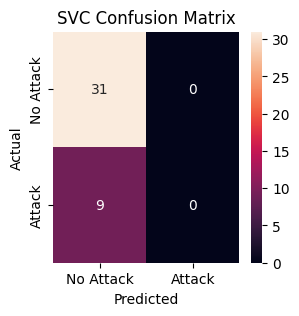

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        31
           1       0.00      0.00      0.00         9

    accuracy                           0.78        40
   macro avg       0.39      0.50      0.44        40
weighted avg       0.60      0.78      0.68        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
svc_model = SVC(random_state=42)
svc_model.fit(X_train_encoded, y_train)
svc_pred = svc_model.predict(X_test_encoded)

print('SVC Training score:', svc_model.score(X_train_encoded, y_train) * 100)
print('SVC Testing score:', svc_model.score(X_test_encoded, y_test) * 100)

svc_cm = confusion_matrix(y_test, svc_pred)
plt.figure(figsize=(3,3))
sns.heatmap(svc_cm, annot=True, fmt='d', xticklabels=['No Attack','Attack'], yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVC Confusion Matrix')
plt.show()

print('SVC Classification Report:')
print(classification_report(y_test, svc_pred))

### Gaussian Naive Bayes (GaussianNB)

GaussianNB Training score: 76.875
GaussianNB Testing score: 87.5


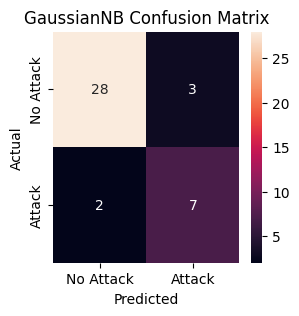

GaussianNB Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        31
           1       0.70      0.78      0.74         9

    accuracy                           0.88        40
   macro avg       0.82      0.84      0.83        40
weighted avg       0.88      0.88      0.88        40



In [29]:
gnb_model = GaussianNB()
gnb_model.fit(X_train_encoded, y_train)
gnb_pred = gnb_model.predict(X_test_encoded)

print('GaussianNB Training score:', gnb_model.score(X_train_encoded, y_train) * 100)
print('GaussianNB Testing score:', gnb_model.score(X_test_encoded, y_test) * 100)

gnb_cm = confusion_matrix(y_test, gnb_pred)
plt.figure(figsize=(3,3))
sns.heatmap(gnb_cm, annot=True, fmt='d', xticklabels=['No Attack','Attack'], yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GaussianNB Confusion Matrix')
plt.show()

print('GaussianNB Classification Report:')
print(classification_report(y_test, gnb_pred))

### Random Forest Classifier

Random Forest Training score: 100.0
Random Forest Testing score: 97.5


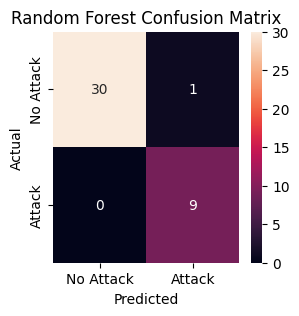

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       0.90      1.00      0.95         9

    accuracy                           0.97        40
   macro avg       0.95      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



In [30]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_encoded, y_train)
rf_pred = rf_model.predict(X_test_encoded)

print('Random Forest Training score:', rf_model.score(X_train_encoded, y_train) * 100)
print('Random Forest Testing score:', rf_model.score(X_test_encoded, y_test) * 100)

rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(3,3))
sns.heatmap(rf_cm, annot=True, fmt='d', xticklabels=['No Attack','Attack'], yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

print('Random Forest Classification Report:')
print(classification_report(y_test, rf_pred))